# Lab 2 - Aral Sea water decline: Landsat 2000-2005 vs Landsat 9 (2025)

The Aral Sea lost most of its water between the 1960s and today - one of the
largest environmental disasters of the 20th century.  In this lab you will
quantify that change using two Landsat mosaics and spectral water indices.

What's provided: the early-2000s data acquisition and the NDWI reference implementation.  
What you write: Landsat 9 search (Task 1), two more water indices (Task 2),
and a scene footprint map (Task 3).


## Setup


In [13]:
import warnings
warnings.filterwarnings('ignore')

import os
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import PatchCollection

import rasterio
from rasterio.warp import reproject, Resampling, transform_bounds
from rasterio.transform import from_bounds as make_transform
from rasterio.crs import CRS

import pystac_client
import planetary_computer

# ---------------------------------------------------------------------------
# Area of Interest: Aral Sea region in WGS84 (lon_min, lat_min, lon_max, lat_max)
# This bounding box covers both the North and South Aral basins.
BBOX = [57.5, 43.5, 62.5, 46.8]

# Summer window: July-September gives the least cloud cover over Central Asia.
SEASON = ('07-01', '09-30')

# Year ranges for each sensor
LS_YEARS = range(2000, 2006)   # Landsat 5 / 7 -- the lake was still partially full
LS9_YEAR = 2025                # Landsat 9 -- launched September 2021

# MAX_SCENES is the hard cap on how many scenes are downloaded per sensor.
# Challenge 1.1 asks you to find the right value for full coverage.
MAX_SCENES = 65

# How many of the least-cloudy scenes to keep per WRS path/row strip.
# Increasing this ensures gaps from cloud or SLC-off are filled by the median.
SCENES_PER_STRIP = 4

# Output grid: reproject everything to UTM zone 41N (EPSG:32641).
# 300 m/pixel is fast to compute; lower values give sharper images.
RESOLUTION  = 300
TARGET_CRS  = CRS.from_epsg(32641)
WGS84       = CRS.from_epsg(4326)
UTM_BOUNDS  = transform_bounds(WGS84, TARGET_CRS, *BBOX)
GRID_WIDTH  = int((UTM_BOUNDS[2] - UTM_BOUNDS[0]) / RESOLUTION)
GRID_HEIGHT = int((UTM_BOUNDS[3] - UTM_BOUNDS[1]) / RESOLUTION)
GRID_TRANSFORM = make_transform(*UTM_BOUNDS, GRID_WIDTH, GRID_HEIGHT)

# Local directories where downloaded band files are cached.
# Re-running the download cells is safe -- existing files are skipped.
DIR_LS  = '../data/downloads/landsat_early'
DIR_LS9 = '../data/downloads/landsat9_2025'
os.makedirs(DIR_LS,  exist_ok=True)
os.makedirs(DIR_LS9, exist_ok=True)

print(f'Output grid : {GRID_WIDTH} x {GRID_HEIGHT} pixels  @ {RESOLUTION} m/px')
print(f'Download dirs: {DIR_LS}  |  {DIR_LS9}')


Output grid : 1355 x 1270 pixels  @ 300 m/px
Download dirs: ../data/downloads/landsat_early  |  ../data/downloads/landsat9_2025


## Connect to the STAC catalogue

We use Microsoft Planetary Computer, which serves Landsat Collection-2 Level-2
surface-reflectance data through a STAC API.  `sign_inplace` attaches short-lived
access tokens so rasterio can stream directly from the cloud files.


In [14]:
catalog = pystac_client.Client.open(
    'https://planetarycomputer.microsoft.com/api/stac/v1',
    modifier=planetary_computer.sign_inplace,  # automatically re-signs expired tokens
)
print('Connected:', catalog.title)


Connected: Microsoft Planetary Computer STAC API


## Band-loading helpers

Four utility functions that handle the rasterio/reprojection work.
Read the docstrings - you'll call `download_band` and `median_mosaic_from_files`
when writing Task 1.


In [15]:
# Band name aliases handle the fact that Planetary Computer uses different
# key names across Landsat 5, 7, and 9 items.
BAND_ALIASES = {
    'blue':   ['blue',  'B02'],
    'green':  ['green', 'B03'],
    'red':    ['red',   'B04'],
    'nir08':  ['nir08', 'nir', 'B08', 'B8A'],
    'swir16': ['swir16', 'swir', 'B11'],
}


def get_asset_href(item, common_name):
    """
    Return the signed HTTPS URL for a band by its common name.
    Falls back through the alias list so the same call works for
    Landsat 5, 7, and 9.
    """
    aliases = BAND_ALIASES.get(common_name, [common_name])
    # First try matching the 'common_name' field inside each asset's eo:bands metadata
    for asset in item.assets.values():
        for band in asset.extra_fields.get('eo:bands', []):
            if band.get('common_name') in aliases:
                return asset.href
    # Fallback: try the asset key directly (e.g. 'blue', 'B02')
    for alias in aliases:
        if alias in item.assets:
            return item.assets[alias].href
    raise KeyError(f"Band '{common_name}' not found. Available: {list(item.assets.keys())}")


def reproject_to_grid(href):
    """
    Open a Cloud-Optimised GeoTIFF at `href` and reproject it onto the
    common UTM output grid defined by GRID_TRANSFORM / TARGET_CRS.
    rasterio only reads the tiles that overlap the output window,
    so only the AOI portion of each scene is transferred over the network.
    Returns a 2-D float32 numpy array.
    """
    out = np.zeros((GRID_HEIGHT, GRID_WIDTH), dtype=np.float32)
    with rasterio.open(href) as src:
        reproject(
            source=rasterio.band(src, 1),
            destination=out,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=GRID_TRANSFORM,
            dst_crs=TARGET_CRS,
            resampling=Resampling.average,  # average downsample for 300-m output
            src_nodata=src.nodata,
            dst_nodata=0.0,
        )
    return out


def download_band(item, band_name, save_dir, scale, offset=0.0):
    """
    Download one band from a STAC item, apply the Landsat surface-reflectance
    scale and offset (SR = DN * scale + offset), and save the result as a
    local float32 GeoTIFF aligned to the common UTM grid.

    The Landsat C2 L2 scale/offset values are: scale=0.0000275, offset=-0.2
    These convert the integer DN stored in the COG to physical reflectance [0, 1].

    Returns the local file path.  Skips the network download if the file
    already exists, so re-running this cell is fast.
    """
    fname = os.path.join(save_dir, f'{item.id}__{band_name}.tif')
    if os.path.exists(fname):
        return fname  # already downloaded -- skip

    href = get_asset_href(item, band_name)
    arr  = reproject_to_grid(href)
    # Convert integer DN to reflectance and clip to [0, 1]
    arr  = np.clip(arr.astype(np.float32) * scale + offset, 0, 1)

    with rasterio.open(
        fname, 'w', driver='GTiff',
        height=GRID_HEIGHT, width=GRID_WIDTH,
        count=1, dtype='float32',
        crs=TARGET_CRS, transform=GRID_TRANSFORM,
        nodata=0.0,
    ) as dst:
        dst.write(arr, 1)
    return fname


def median_mosaic_from_files(file_paths):
    """
    Load a set of local GeoTIFFs and return their per-pixel nanmedian.
    Zero pixels (no-data) are masked before the median so they do not
    drag the result towards zero in partially-covered areas.
    Returns a 2-D float32 array.
    """
    stack = []
    for fp in file_paths:
        with rasterio.open(fp) as src:
            arr = src.read(1).astype(np.float32)
        arr[arr <= 0] = np.nan   # treat no-data as missing
        stack.append(arr)
    # nanmedian ignores NaN; converts any remaining NaN back to 0
    return np.nan_to_num(
        np.nanmedian(np.stack(stack, axis=0), axis=0),
        nan=0.0,
    ).astype(np.float32)


print('Helpers ready.')


Helpers ready.


## Part 1 - Early 2000s Landsat mosaic

Run both cells below as-is.  The code searches Planetary Computer for the
least-cloudy summer scenes from 2000-2005 and downloads the five bands we need.

**Why group by WRS path/row?**  
Each Landsat scene covers a ~185 km strip.  The Aral Sea spans several strips.
Picking scenes purely by cloud cover would fill all slots with scenes from the
same clear strip and leave others blank.  Grouping by path/row first ensures
every strip gets represented before the global cap is applied.


In [16]:
ls_all = []
# Search each summer year separately so we can pull the best scenes
# across the whole 2000-2005 window rather than a single year.
for year in LS_YEARS:
    search = catalog.search(
        collections=['landsat-c2-l2'],   # Landsat Collection-2 Level-2
        bbox=BBOX,
        datetime=f'{year}-{SEASON[0]}/{year}-{SEASON[1]}',
        query={'eo:cloud_cover': {'lt': 60}},  # pre-filter; median handles residual cloud
    )
    ls_all.extend(search.items())

# Sort the full candidate pool by cloud cover (least cloudy first)
ls_all.sort(key=lambda x: x.properties.get('eo:cloud_cover', 100))

# Group by WRS-2 path/row so every orbital strip is represented
by_strip = defaultdict(list)
for item in ls_all:
    key = (item.properties.get('landsat:wrs_path', '?'),
           item.properties.get('landsat:wrs_row',  '?'))
    by_strip[key].append(item)  # list is already cloud-sorted

# For each strip keep only the SCENES_PER_STRIP least-cloudy scenes,
# then apply the global MAX_SCENES cap (keeping the least-cloudy overall)
ls_selected = []
for strip_items in by_strip.values():
    ls_selected.extend(strip_items[:SCENES_PER_STRIP])
ls_selected.sort(key=lambda x: x.properties.get('eo:cloud_cover', 100))
ls_selected = ls_selected[:MAX_SCENES]

print(f'Found {len(ls_all)} candidates, {len(by_strip)} WRS strips, '
      f'using {len(ls_selected)} scenes for the mosaic')
for (path, row), items in sorted(by_strip.items()):
    best  = items[0].properties.get('eo:cloud_cover', float('nan'))
    plat  = items[0].properties.get('platform', '?')
    print(f'  path/row {path}/{row}  {plat:<12}  '
          f'{len(items)} candidates, best cloud={best:.1f}%')


Found 452 candidates, 21 WRS strips, using 65 scenes for the mosaic
  path/row 158/029  landsat-5     1 candidates, best cloud=0.0%
  path/row 158/030  landsat-7     25 candidates, best cloud=0.0%
  path/row 159/027  landsat-7     10 candidates, best cloud=0.0%
  path/row 159/028  landsat-7     13 candidates, best cloud=0.0%
  path/row 159/029  landsat-5     22 candidates, best cloud=0.0%
  path/row 159/030  landsat-5     22 candidates, best cloud=0.0%
  path/row 160/027  landsat-7     12 candidates, best cloud=0.0%
  path/row 160/028  landsat-7     24 candidates, best cloud=0.0%
  path/row 160/029  landsat-5     27 candidates, best cloud=0.0%
  path/row 160/030  landsat-7     30 candidates, best cloud=0.0%
  path/row 161/027  landsat-7     14 candidates, best cloud=0.0%
  path/row 161/028  landsat-5     24 candidates, best cloud=0.0%
  path/row 161/029  landsat-5     26 candidates, best cloud=0.0%
  path/row 161/030  landsat-5     30 candidates, best cloud=0.0%
  path/row 162/027  lan

In [17]:
LS_BANDS  = ('blue', 'green', 'red', 'nir08', 'swir16')
LS_SCALE  = 0.0000275  # Landsat C2 L2 reflectance scale factor
LS_OFFSET = -0.2       # Landsat C2 L2 reflectance offset

ls_files = {b: [] for b in LS_BANDS}  # will hold local file paths per band

for i, item in enumerate(ls_selected):
    print(f'[{i+1}/{len(ls_selected)}] {item.id[:55]} ...', end=' ', flush=True)
    for band in LS_BANDS:
        try:
            fp = download_band(item, band, DIR_LS, scale=LS_SCALE, offset=LS_OFFSET)
            ls_files[band].append(fp)
        except Exception as e:
            print(f'\n  WARNING {band}: {e}', end='')
    print('OK')

print(f'\nDone. Files in: {DIR_LS}')


[1/65] LT05_L2SP_162029_20000930_02_T1 ... OK
[2/65] LE07_L2SP_162029_20000906_02_T1 ... OK
[3/65] LT05_L2SP_162029_20000829_02_T1 ... OK
[4/65] LE07_L2SP_162029_20020912_02_T1 ... OK
[5/65] LT05_L2SP_162028_20000930_02_T2 ... OK
[6/65] LE07_L2SP_162028_20000906_02_T1 ... OK
[7/65] LE07_L2SP_162028_20010707_02_T1 ... OK
[8/65] LE07_L2SP_162028_20020710_02_T1 ... OK
[9/65] LT05_L2SP_162027_20000930_02_T2 ... OK
[10/65] LE07_L2SP_162027_20000906_02_T1 ... OK
[11/65] LE07_L2SP_162027_20010909_02_T1 ... OK
[12/65] LE07_L2SP_162027_20030729_02_T1 ... OK
[13/65] LE07_L2SP_163029_20000929_02_T1 ... OK
[14/65] LT05_L2SP_163029_20000921_02_T1 ... OK
[15/65] LT05_L2SP_163029_20000719_02_T1 ... OK
[16/65] LE07_L2SP_163029_20010815_02_T1 ... OK
[17/65] LE07_L2SP_158030_20000926_02_T1 ... OK
[18/65] LE07_L2SP_158030_20000910_02_T1 ... OK
[19/65] LE07_L2SP_158030_20000724_02_T1 ... OK
[20/65] LE07_L2SP_158030_20010929_02_T1 ... OK
[21/65] LT05_L2SP_162030_20000914_02_T1 ... OK
[22/65] LE07_L2SP_1620

## Task 1 - Fetch Landsat 9 scenes for 2025

Write a search that finds Landsat 9 summer scenes for `LS9_YEAR` and picks
the best ones per WRS strip - same logic as the early-2000s cell above.

Hints:
- Collection is `'landsat-c2-l2'`, same `SEASON` window
- Filter to Landsat 9: `'platform': {'in': ['landsat-9']}`
- Group by `landsat:wrs_path` / `landsat:wrs_row`, keep `SCENES_PER_STRIP` per strip
- Cap with `MAX_SCENES`; store the final list in `ls9_selected`


In [18]:
# ---- Task 1: write your Landsat 9 search here ----

# TODO: search the 'landsat-c2-l2' collection for LS9_YEAR summer scenes
#       filtered to platform='landsat-9' and cloud_cover < 60
ls9_search = catalog.search(
    collections=['landsat-c2-l2'],
    bbox=BBOX,
    datetime=f'{LS9_YEAR}-{SEASON[0]}/{LS9_YEAR}-{SEASON[1]}',
    query={
        'eo:cloud_cover': {'lt': 60},
        'platform': {'in': ['landsat-9']},
    },
)

# TODO: sort results by cloud cover
ls9_all = list(ls9_search.items())
ls9_all.sort(key=lambda x: x.properties.get('eo:cloud_cover', 100))

# TODO: group by WRS path/row (same logic as the early-2000s cell above)
by_strip9 = defaultdict(list)
for item in ls9_all:
    key = (
        item.properties.get('landsat:wrs_path', '?'),
        item.properties.get('landsat:wrs_row', '?'),
    )
    by_strip9[key].append(item)

# Select SCENES_PER_STRIP per strip, then cap at MAX_SCENES
ls9_selected = []
for strip_items in by_strip9.values():
    ls9_selected.extend(strip_items[:SCENES_PER_STRIP])

# TODO: select SCENES_PER_STRIP per strip, then cap at MAX_SCENES
ls9_selected.sort(key=lambda x: x.properties.get('eo:cloud_cover', 100))
ls9_selected = ls9_selected[:MAX_SCENES]

print(f'Selected {len(ls9_selected)} Landsat 9 scenes')


Selected 65 Landsat 9 scenes


### Task 1.1 - Get 100% coverage

Run the download cell, build the mosaics, and check the coverage number.
If it's below 100%, go back to the config cell and raise `MAX_SCENES`
or `SCENES_PER_STRIP`, then re-run from Task 1.

Worth thinking about: how many WRS strips cross the AOI, and what's the
minimum number of scenes needed to cover all of them?


In [19]:
LS9_BANDS = ('blue', 'green', 'red', 'nir08', 'swir16')
# Landsat 9 C2 L2 uses the same scale/offset as Landsat 5 and 7

ls9_files = {b: [] for b in LS9_BANDS}

for i, item in enumerate(ls9_selected):
    print(f'[{i+1}/{len(ls9_selected)}] {item.id[:55]} ...', end=' ', flush=True)
    for band in LS9_BANDS:
        try:
            fp = download_band(item, band, DIR_LS9, scale=0.0000275, offset=-0.2)
            ls9_files[band].append(fp)
        except Exception as e:
            print(f'\n  WARNING {band}: {e}', end='')
    print('OK')

print(f'\nDone. Files in: {DIR_LS9}')


[1/65] LC09_L2SP_161029_20250904_02_T1 ... OK
[2/65] LC09_L2SP_161029_20250819_02_T1 ... OK
[3/65] LC09_L2SP_163029_20250902_02_T1 ... OK
[4/65] LC09_L2SP_163028_20250902_02_T1 ... OK
[5/65] LC09_L2SP_158030_20250830_02_T1 ... OK
[6/65] LC09_L2SP_158030_20250814_02_T1 ... OK
[7/65] LC09_L2SP_160030_20250828_02_T1 ... OK
[8/65] LC09_L2SP_160030_20250812_02_T1 ... OK
[9/65] LC09_L2SP_162030_20250826_02_T1 ... OK
[10/65] LC09_L2SP_162030_20250709_02_T1 ... OK
[11/65] LC09_L2SP_162029_20250826_02_T1 ... OK
[12/65] LC09_L2SP_162029_20250709_02_T1 ... OK
[13/65] LC09_L2SP_159030_20250821_02_T1 ... OK
[14/65] LC09_L2SP_159030_20250805_02_T1 ... OK
[15/65] LC09_L2SP_159030_20250720_02_T1 ... OK
[16/65] LC09_L2SP_159029_20250821_02_T1 ... OK
[17/65] LC09_L2SP_159029_20250805_02_T1 ... OK
[18/65] LC09_L2SP_159029_20250720_02_T1 ... OK
[19/65] LC09_L2SP_159028_20250821_02_T1 ... OK
[20/65] LC09_L2SP_159028_20250805_02_T1 ... OK
[21/65] LC09_L2SP_159028_20250720_02_T1 ... OK
[22/65] LC09_L2SP_1610

## Build median mosaics

Reads from the local files downloaded above - no more network traffic.
Coverage is the fraction of the output grid with valid pixels.


In [20]:
print('Building early-2000s Landsat mosaic ...', end=' ', flush=True)
ls_mosaic = {b: median_mosaic_from_files(ls_files[b]) for b in LS_BANDS}
ls_coverage = np.mean(ls_mosaic['green'] > 0) * 100
print(f'coverage = {ls_coverage:.0f}%')

print('Building Landsat 9 mosaic ...', end=' ', flush=True)
ls9_mosaic = {b: median_mosaic_from_files(ls9_files[b]) for b in LS9_BANDS}
ls9_coverage = np.mean(ls9_mosaic['green'] > 0) * 100
print(f'coverage = {ls9_coverage:.0f}%')

if ls9_coverage < 99:
    print('\nTip: coverage is below 100%. Go back to the config cell and '
          'increase MAX_SCENES or SCENES_PER_STRIP, then re-run from Challenge 1.')


Building early-2000s Landsat mosaic ... coverage = 100%
Building Landsat 9 mosaic ... coverage = 100%


## True colour comparison

Per-channel 2-98% stretch prevents the bright salt flats from washing out
the water and vegetation.


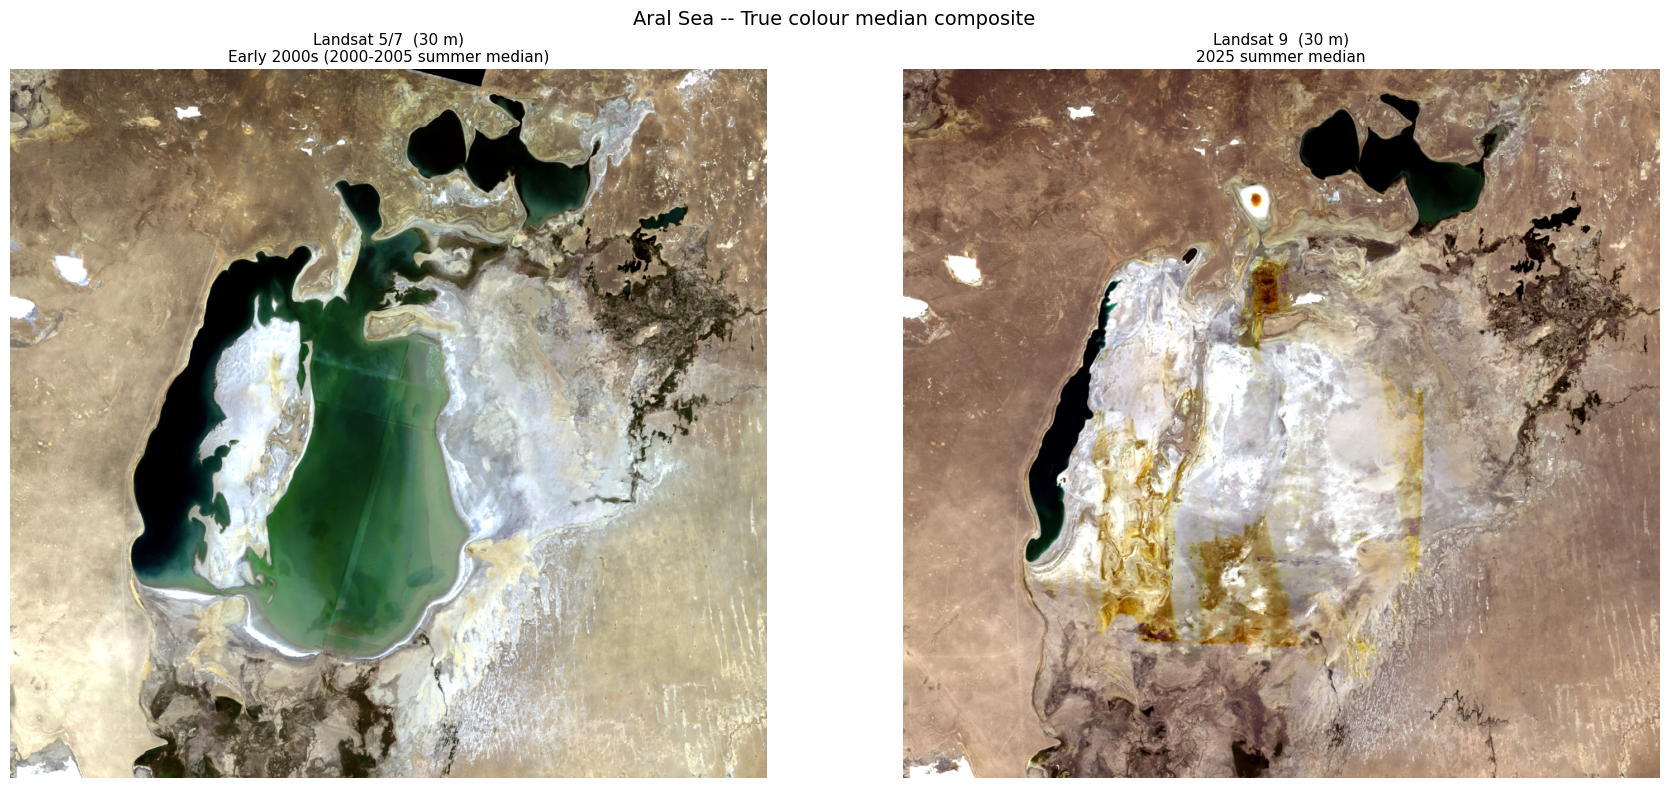

In [21]:
def to_rgb(mosaic):
    """Stack R/G/B bands and apply per-channel 2-98% linear stretch."""
    rgb = np.stack([mosaic['red'], mosaic['green'], mosaic['blue']], axis=-1)
    for ch in range(3):
        band  = rgb[..., ch]
        valid = band[band > 0]
        if valid.size:
            lo, hi = np.percentile(valid, [2, 98])
            rgb[..., ch] = np.clip((band - lo) / (hi - lo + 1e-9), 0, 1)
    return rgb


ls_rgb  = to_rgb(ls_mosaic)
ls9_rgb = to_rgb(ls9_mosaic)

fig, axes = plt.subplots(1, 2, figsize=(18, 8), subplot_kw={'aspect': 'equal'})
fig.suptitle('Aral Sea -- True colour median composite', fontsize=14)

axes[0].imshow(ls_rgb, interpolation='bilinear')
axes[0].set_title('Landsat 5/7  (30 m)\nEarly 2000s (2000-2005 summer median)', fontsize=11)
axes[0].axis('off')

axes[1].imshow(ls9_rgb, interpolation='bilinear')
axes[1].set_title(f'Landsat 9  (30 m)\n{LS9_YEAR} summer median', fontsize=11)
axes[1].axis('off')

plt.tight_layout()
plt.show()


## NDWI (reference implementation)

NDWI (McFeeters, 1996) exploits the fact that water absorbs NIR strongly
while reflecting green fairly well:

```
NDWI = (Green - NIR) / (Green + NIR)
```

Values above zero are generally open water.  Study this cell before Task 2 -
your indices follow the same structure.


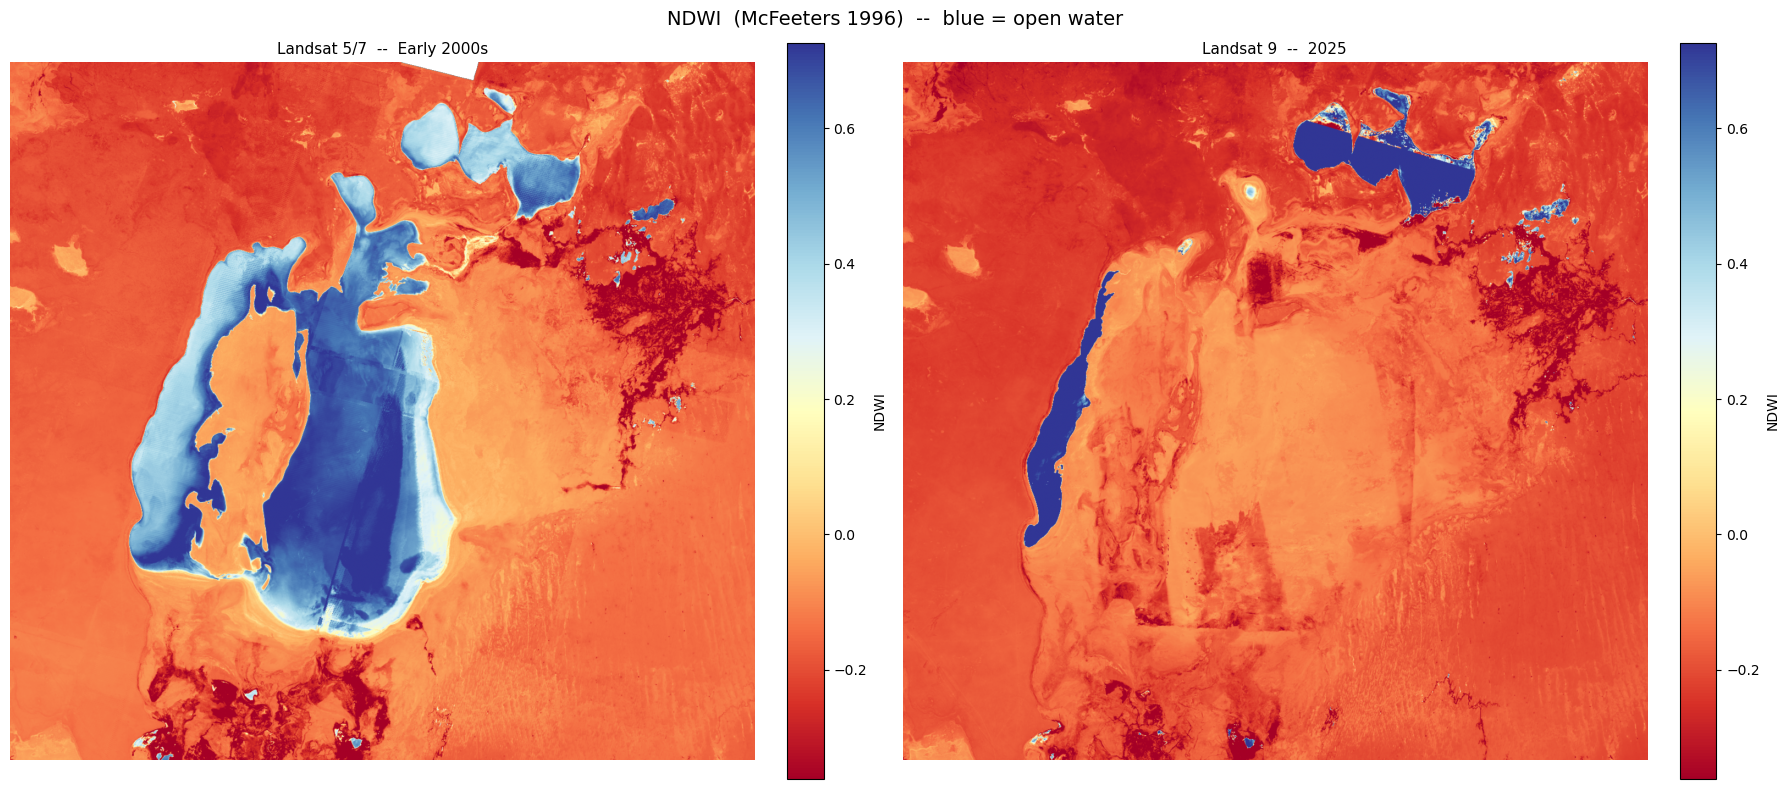

Early 2000s: ~26,639 km2 of open water  (NDWI > 0)
2025: ~5,296 km2 of open water  (NDWI > 0)


In [22]:
def compute_ndwi(mosaic):
    """NDWI (McFeeters 1996): (Green - NIR) / (Green + NIR)"""
    g = mosaic['green']
    n = mosaic['nir08']
    ndwi = (g - n) / (g + n + 1e-9)   # add epsilon to avoid division by zero
    ndwi[(g == 0) & (n == 0)] = np.nan  # mask no-data pixels
    return ndwi


# Compute NDWI for both eras
ls_ndwi  = compute_ndwi(ls_mosaic)
ls9_ndwi = compute_ndwi(ls9_mosaic)

# Build a shared colour scale from the combined data range
combined = np.concatenate([ls_ndwi[np.isfinite(ls_ndwi)],
                           ls9_ndwi[np.isfinite(ls9_ndwi)]])
vmin, vmax = np.percentile(combined, [2, 98])

fig, axes = plt.subplots(1, 2, figsize=(18, 8), subplot_kw={'aspect': 'equal'})
fig.suptitle('NDWI  (McFeeters 1996)  --  blue = open water', fontsize=14)

for ax, ndwi, title in [
    (axes[0], ls_ndwi,  'Landsat 5/7  --  Early 2000s'),
    (axes[1], ls9_ndwi, f'Landsat 9  --  {LS9_YEAR}'),
]:
    im = ax.imshow(ndwi, cmap='RdYlBu', vmin=vmin, vmax=vmax,
                   interpolation='bilinear')
    ax.set_title(title, fontsize=11)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='NDWI')

plt.tight_layout()
plt.show()

pix_km2 = (RESOLUTION / 1000) ** 2
for label, ndwi in [('Early 2000s', ls_ndwi), (str(LS9_YEAR), ls9_ndwi)]:
    area = int(np.nansum(ndwi > 0)) * pix_km2
    print(f'{label}: ~{area:,.0f} km2 of open water  (NDWI > 0)')


## Task 2 - Two more water indices

NDWI sometimes flags built-up areas as water because NIR reflectance over
concrete can be low.  The SWIR band is more selective:

**MNDWI** (Xu, 2006) - swaps NIR for SWIR16:
```
MNDWI = (Green - SWIR16) / (Green + SWIR16)
```

**WRI** (Shen & Li, 2010) - a four-band ratio; values above 1 indicate water:
```
WRI = (Green + Red) / (NIR + SWIR16)
```

Implement both functions, compute them for both eras, and plot all three
indices together.  Where do they agree?  Pay attention to the salt flats and
the irrigated fields south of the lake - that's where differences show up.


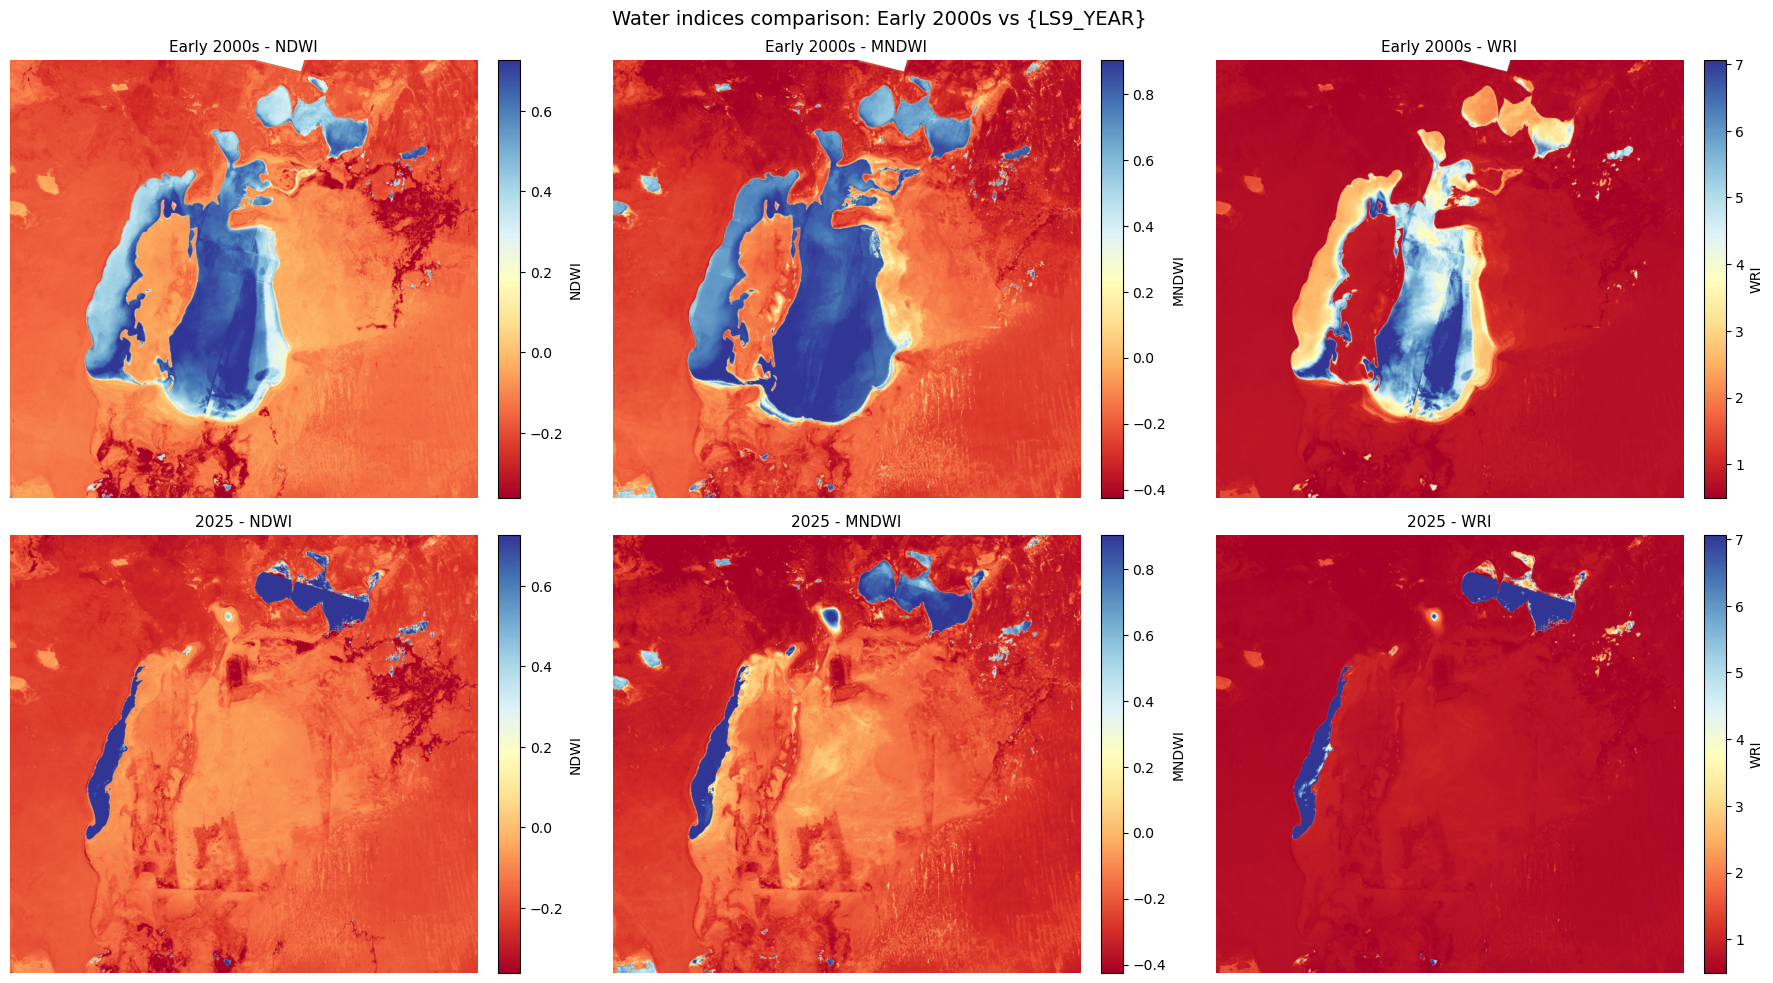

In [23]:
# ---- Task 2: implement MNDWI and WRI ----

def compute_mndwi(mosaic):
    """MNDWI (Xu 2006): (Green - SWIR16) / (Green + SWIR16)"""
    # TODO: extract mosaic['green'] and mosaic['swir16']
    # TODO: compute the normalised difference
    # TODO: mask no-data pixels (same pattern as compute_ndwi)
    g = mosaic['green']
    s = mosaic['swir16']
    mndwi = (g - s) / (g + s + 1e-9)
    mndwi[(g == 0) & (s == 0)] = np.nan
    return mndwi


def compute_wri(mosaic):
    """WRI (Shen & Li 2010): (Green + Red) / (NIR + SWIR16)"""
    # TODO: extract the four required bands from mosaic
    # TODO: compute the ratio
    # TODO: mask no-data pixels (where all four bands are zero)
    g = mosaic['green']
    r = mosaic['red']
    n = mosaic['nir08']
    s = mosaic['swir16']
    wri = (g + r) / (n + s + 1e-9)
    wri[(g == 0) & (r == 0) & (n == 0) & (s == 0)] = np.nan
    return wri


# TODO: compute both indices for ls_mosaic and ls9_mosaic
ls_mndwi  = compute_mndwi(ls_mosaic)
ls9_mndwi = compute_mndwi(ls9_mosaic)
ls_wri    = compute_wri(ls_mosaic)
ls9_wri   = compute_wri(ls9_mosaic)

# TODO: plot all three indices side-by-side for both eras
# Tip: use a 2x3 subplot grid (2 eras x 3 indices)
# Use a shared colour scale per index (combine both eras before calling np.percentile)
fig, axes = plt.subplots(2, 3, figsize=(18, 10), subplot_kw={'aspect': 'equal'})
fig.suptitle('Water indices comparison: Early 2000s vs {LS9_YEAR}', fontsize=14)

# Shared colour scales per index
# NDWI
ndwi_combined = np.concatenate([
    ls_ndwi[np.isfinite(ls_ndwi)],
    ls9_ndwi[np.isfinite(ls9_ndwi)],
])
ndwi_vmin, ndwi_vmax = np.percentile(ndwi_combined, [2, 98])

# MNDWI
mndwi_combined = np.concatenate([
    ls_mndwi[np.isfinite(ls_mndwi)],
    ls9_mndwi[np.isfinite(ls9_mndwi)],
])
mndwi_vmin, mndwi_vmax = np.percentile(mndwi_combined, [2, 98])

# WRI
wri_combined = np.concatenate([
    ls_wri[np.isfinite(ls_wri)],
    ls9_wri[np.isfinite(ls9_wri)],
])
wri_vmin, wri_vmax = np.percentile(wri_combined, [2, 98])

# Row 0: Early 2000s, Row 1: LS9_YEAR
index_data = [
    (ls_ndwi,  ndwi_vmin,  ndwi_vmax,  'NDWI'),
    (ls_mndwi, mndwi_vmin, mndwi_vmax, 'MNDWI'),
    (ls_wri,   wri_vmin,   wri_vmax,   'WRI'),
]

for col, (data_early, vmin, vmax, label) in enumerate(index_data):
    im = axes[0, col].imshow(data_early, cmap='RdYlBu', vmin=vmin, vmax=vmax,
                             interpolation='bilinear')
    axes[0, col].set_title(f'Early 2000s - {label}', fontsize=11)
    axes[0, col].axis('off')
    plt.colorbar(im, ax=axes[0, col], fraction=0.046, pad=0.04, label=label)

index_data_l9 = [
    (ls9_ndwi,  ndwi_vmin,  ndwi_vmax,  'NDWI'),
    (ls9_mndwi, mndwi_vmin, mndwi_vmax, 'MNDWI'),
    (ls9_wri,   wri_vmin,   wri_vmax,   'WRI'),
]

for col, (data_l9, vmin, vmax, label) in enumerate(index_data_l9):
    im = axes[1, col].imshow(data_l9, cmap='RdYlBu', vmin=vmin, vmax=vmax,
                             interpolation='bilinear')
    axes[1, col].set_title(f'{LS9_YEAR} - {label}', fontsize=11)
    axes[1, col].axis('off')
    plt.colorbar(im, ax=axes[1, col], fraction=0.046, pad=0.04, label=label)

plt.tight_layout()
plt.show()


## Task 3 - Scene footprint map

Draw the geographic footprint of every selected scene on a map, coloured
by era.  This makes it immediately clear why the WRS strip grouping was needed
and which parts of the AOI are covered by multiple overlapping scenes.

Steps:
1. Get the polygon for each item: `item.geometry['coordinates'][0]` is a list
   of `[lon, lat]` pairs for the outer ring
2. Early-2000s footprints in one colour, Landsat 9 in another (use alpha so
   overlaps are visible)
3. Draw the AOI (`BBOX`) as a dashed rectangle
4. Add a legend and axis labels

Available: `MplPolygon`, `PatchCollection` (both already imported).  
`BBOX = [lon_min, lat_min, lon_max, lat_max]`.


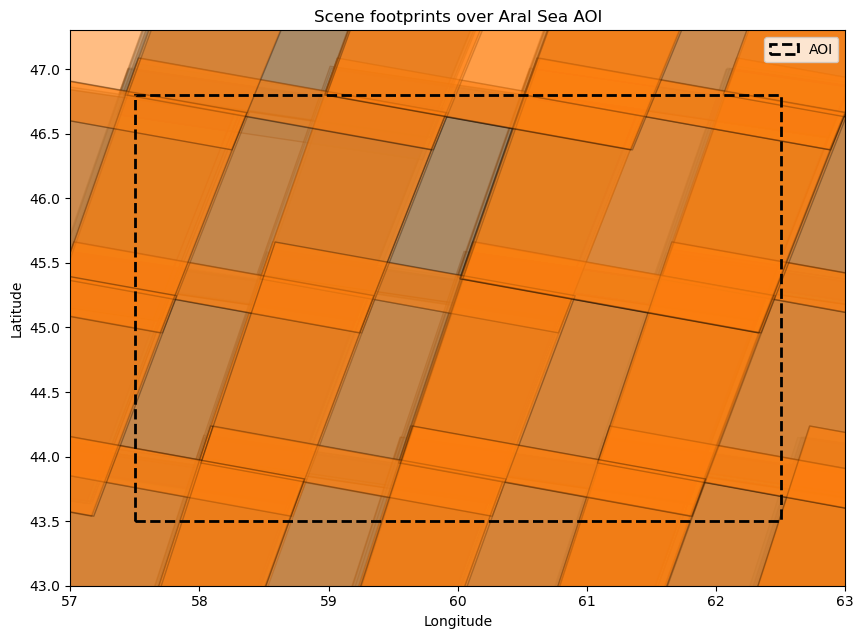

In [24]:
# ---- Task 3: draw scene footprints over the AOI ----

fig, ax = plt.subplots(figsize=(10, 8))

# TODO: for each item in ls_selected, extract the polygon coordinates
#       and add a MplPolygon patch to a list, then plot with PatchCollection
# Early 2000s footprints
early_patches = []
for item in ls_selected:
    if item.geometry is None:
        continue
    coords = item.geometry['coordinates'][0]
    poly = MplPolygon(coords, closed=True)
    early_patches.append(poly)


if early_patches:
    early_coll = PatchCollection(
        early_patches,
        facecolor='tab:blue',
        edgecolor='k',
        alpha=0.3,
        label='Landsat 5/7 (2000–2005)',
    )
    ax.add_collection(early_coll)

# TODO: repeat for ls9_selected in a different colour
# Landsat 9 footprints
ls9_patches = []
for item in ls9_selected:
    if item.geometry is None:
        continue
    coords = item.geometry['coordinates'][0]
    poly = MplPolygon(coords, closed=True)
    ls9_patches.append(poly)

if ls9_patches:
    ls9_coll = PatchCollection(
        ls9_patches,
        facecolor='tab:orange',
        edgecolor='k',
        alpha=0.3,
        label=f'Landsat 9 ({LS9_YEAR})',
    )
    ax.add_collection(ls9_coll)

# TODO: draw the AOI bounding box (BBOX) as a rectangle
#       Hint: matplotlib.patches.Rectangle(xy, width, height, ...)
lon_min, lat_min, lon_max, lat_max = BBOX
width = lon_max - lon_min
height = lat_max - lat_min
bbox_rect = mpatches.Rectangle(
    (lon_min, lat_min),
    width,
    height,
    fill=False,
    linestyle='--',
    edgecolor='black',
    linewidth=2,
    label='AOI',
)
ax.add_patch(bbox_rect)

# TODO: add legend, axis labels, title
ax.set_xlim(lon_min - 0.5, lon_max + 0.5)
ax.set_ylim(lat_min - 0.5, lat_max + 0.5)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Scene footprints over Aral Sea AOI')
ax.legend(loc='upper right')

ax.set_aspect('equal')
plt.show()
